# Máquinas Térmicas - Lección 7
## Modelación de la Combustión — Balances de Masa y Energía

**Autor:** Camilo Bayona
**Fecha:** 12/08/2025

*Este cuaderno responde **cuánto**: los totales de masa y energía que intercambia la combustión. La Lección 8 (Cinética de la Combustión) responde **qué tan rápido**, usando las herramientas que se construyen aquí.*

### Objetivos de aprendizaje
1. Balancear reacciones globales de combustión resolviendo el sistema algebraico de conservación de átomos, hasta combustibles generales $C_mH_nN_oS_p$.
2. Calcular el calor de reacción y el poder calorífico a partir de entalpías de formación (HHV/LHV) y evaluar la eficiencia de combustión.
3. Determinar la relación aire-combustible estequiométrica y el efecto del exceso/defecto de aire ($\lambda$) sobre el calor liberado y la temperatura de llama adiabática.
4. Interpretar los análisis próximo y último de un combustible sólido y convertir entre ellos.

In [1]:
# Instalación solo en Google Colab; en el entorno local del curso es un no-op
import sys
if "google.colab" in sys.modules:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "matplotlib", "ipywidgets", "numpy", "scipy", "CoolProp"], check=True)

In [2]:
# === Setup =================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown, Checkbox
from IPython.display import display, Math
from CoolProp.CoolProp import PropsSI

trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz  # NumPy 2.x eliminó np.trapz

# Paleta fija de especies (idéntica en las Lecciones 7, 8 y 8b)
COL = {"fuel": "#2a78d6", "O2": "#e34948", "H2O": "#1baf7a", "CO2": "#eda100",
       "SO2": "#4a3aa7", "NOx": "#eb6834", "N2": "#8a8a86", "tinta": "#3a3a38"}

# Masas molares [g/mol] — de CoolProp cuando el fluido existe; atómicas de IUPAC
MM = {f: PropsSI("M", f) * 1000 for f in
      ["CO2", "Water", "Oxygen", "Nitrogen", "SulfurDioxide", "Methane", "Propane", "Hydrogen", "n-Octane"]}
M_C, M_S, M_N, M_H = 12.011, 32.06, 14.007, 1.008        # átomos [g/mol]
M_aire = (MM["Oxygen"] + 3.76 * MM["Nitrogen"]) / 4.76    # aire del modelo O2 + 3.76 N2

# Entalpías de formación estándar a 298 K [kJ/mol] (Çengel & Boles, Tabla A-26)
Hf = {"CO2": -393.52, "H2O_g": -241.82, "H2O_l": -285.83, "SO2": -296.83, "NO2": 33.2,
      "CH4": -74.85, "C3H8": -103.85, "C8H18_l": -249.95,
      "O2": 0.0, "N2": 0.0, "H2": 0.0, "C": 0.0, "S": 0.0}

print(f"Setup OK — M_aire = {M_aire:.2f} g/mol; CoolProp cargó {len(MM)} fluidos")

Setup OK — M_aire = 28.85 g/mol; CoolProp cargó 9 fluidos


## 1. Modelación de la Combustión

Este cuaderno se centrará en la modelación matemática para representar la combustión. Preliminarmente tenemos que recordar los balances estequiométricos (Resolviendo un Sistema de Ecuaciones Algebraicas)

### 1.1 Balance de Masa (estequiométrico)

El balance estequiométrico es un método fundamental para analizar reacciones químicas, garantizando que la cantidad de masa se conserve en ambos lados de la ecuación. Esto implica que los átomos de cada elemento presentes en los reactivos deben ser iguales a los presentes en los productos. Para resolverlo, podemos plantear un sistema de ecuaciones algebraicas que corresponden a la conservación de cada uno de los elementos.

Consideremos la siguiente reacción genérica de combustión de un hidrocarburo $C_xH_y$ con oxígeno:

$$C_xH_y + O_2 \rightarrow CO_2 + H_2O$$

Nuestro objetivo es balancear esta reacción mediante un sistema de ecuaciones. Los coeficientes estequiométricos a determinar son: $a$ para $C_xH_y$, $b$ para $O_2$, $c$ para $CO_2$ y $d$ para $H_2O$. La reacción química balanceada se expresa de la siguiente manera:

$$aC_xH_y + bO_2 \rightarrow cCO_2 + dH_2O$$

Para realizar el balance estequiométrico, debemos aplicar la conservación de los átomos de cada elemento en ambos lados de la ecuación.

El número de átomos de carbono en los reactivos es $a\,x$, y en los productos es $c$. Por lo tanto, la ecuación correspondiente al carbono es:

$$a\,x = c$$

El número de átomos de hidrógeno en los reactivos es $a\,y$, y en los productos es $2d$ (cada molécula de $H_2O$ contiene 2 átomos de hidrógeno). Entonces, la ecuación para el hidrógeno es:

$$a\,y = 2d$$

En los reactivos, el número de átomos de oxígeno es $2b$ (porque cada molécula de $O_2$ contiene 2 átomos). En los productos, tenemos $2c$ átomos de oxígeno de $CO_2$ y $d$ átomos de $H_2O$. La ecuación para el oxígeno es:

$$2b = 2c + d$$

Ahora tenemos un sistema de tres ecuaciones:

$$\begin{aligned}
a\,x &= c \\
a\,y &= 2d \\
2b &= 2c + d
\end{aligned}$$

1. Despejamos $c$ de la primera ecuación: $c = a\,x$
2. Despejamos $d$ de la segunda ecuación: $d = \dfrac{a\,y}{2}$
3. Sustituimos $c$ y $d$ en la tercera ecuación: $2b = 2(a x) + \dfrac{a y}{2}$

Resolviendo para $b$, obtenemos el valor de todos los coeficientes estequiométricos.

**Forma matricial.** El mismo sistema se escribe como $\mathbf{E}\,\boldsymbol{\nu} = \mathbf{0}$, donde cada fila de $\mathbf{E}$ es un elemento (C, H, O) y cada columna una especie con coeficiente $\nu_j$ (positivo en reactivos, negativo en productos):

$$\underbrace{\begin{pmatrix} x & 0 & -1 & 0 \\ y & 0 & 0 & -2 \\ 0 & 2 & -2 & -1 \end{pmatrix}}_{\mathbf{E}}
\begin{pmatrix} a \\ b \\ c \\ d \end{pmatrix} = \mathbf{0}$$

donde los coeficientes $\boldsymbol{\nu}$ viven en el **espacio nulo** de $\mathbf{E}$: hay infinitas soluciones proporcionales entre sí y se fija la escala con $a=1$. El siguiente widget resuelve el sistema numéricamente para cualquier $C_xH_y$.

In [ ]:
# WIDGET 1 — balanceador estequiométrico de C_xH_y con O2 (espacio nulo de la matriz elemento-especie)
from scipy.linalg import null_space

def balancear(x=3, y=8):
    E = np.array([[x, 0, -1,  0],     # C
                  [y, 0,  0, -2],     # H
                  [0, 2, -2, -1]],    # O
                 dtype=float)
    nu = null_space(E)[:, 0]
    a, b, c, d = nu / nu[0]                      # normalizamos a = 1
    print("Matriz elemento-especie E (filas C,H,O | columnas a,b,c,d):")
    print(E.astype(int))
    print(f"\nEspacio nulo normalizado (a=1):  a={a:.3g}, b={b:.3g}, c={c:.3g}, d={d:.3g}")
    display(Math(rf"1\,C_{{{x}}}H_{{{y}}} + {b:.3g}\,O_2 \rightarrow {c:.3g}\,CO_2 + {d:.3g}\,H_2O"))
    # chequeo de conservación de átomos
    for el, fila in zip("CHO", E):
        assert abs(fila @ [a, b, c, d]) < 1e-10, f"átomos de {el} no conservados"
    print("✔ Átomos de C, H y O conservados (residuo < 1e-10)")

interact(balancear,
         x=IntSlider(3, min=1, max=12, description="x (átomos C)"),
         y=IntSlider(8, min=2, max=26, step=2, description="y (átomos H)"));

interactive(children=(IntSlider(value=3, description='x (átomos C)', max=12, min=1), IntSlider(value=8, descri…

## 2. Balance de Energía Térmica

La energía térmica neta producida por la combustión se puede calcular utilizando la entalpía de formación de las moléculas involucradas en la reacción. La entalpía de formación es la energía requerida para formar una molécula a partir de sus elementos constituyentes en su estado estándar.

### 2.1 Entalpía de formación

La variación de entalpía estándar de formación se usa en termoquímica para encontrar la variación de entalpía estándar de reacción. Esto se hace restándole la suma de las entalpías estándar de formación de los reactivos a la suma de las entalpías estándar de formación de los productos:

$$\Delta H^\circ_r = \sum_{prod} n_i\, \Delta H^\circ_{f,i} \;-\; \sum_{reac} n_j\, \Delta H^\circ_{f,j}$$

donde $^\circ$ significa "estándar" (298 K, 1 atm), $_r$ "de reacción", $_f$ "de formación" y $n_i$ [mol] son los coeficientes estequiométricos.

La energía térmica neta, o calor de la reacción, se calcula como la diferencia entre la entalpía de los productos y la entalpía de los reactantes. En este caso, como los reactantes están en su estado estándar, sus entalpías de formación son cero. Por lo tanto, la energía térmica neta es simplemente el negativo de la entalpía de formación de los productos multiplicada por el número de moles de los productos.

| Especie | $\Delta H^\circ_f$ [kJ/mol] | Especie | $\Delta H^\circ_f$ [kJ/mol] |
|---|---|---|---|
| $CO_2$ | −393.52 | $CH_4$ | −74.85 |
| $H_2O$ (g) | −241.82 | $C_3H_8$ | −103.85 |
| $H_2O$ (l) | −285.83 | $C_8H_{18}$ (l) | −249.95 |
| $SO_2$ | −296.83 | $O_2,\,N_2,\,H_2,\,C,\,S$ | 0 |

### 2.2 Poder Calorífico

El poder calorífico es la cantidad de energía liberada por la combustión de una unidad de masa de combustible. Se puede calcular integrando la potencia térmica en el tiempo y dividiéndola por la masa del combustible. En este caso, la potencia térmica es simplemente la energía térmica neta dividida por el tiempo de la reacción. Si asumimos que la reacción ocurre instantáneamente, entonces el poder calorífico es simplemente la energía térmica neta dividida por la masa del combustible quemado.

La diferencia entre poder calorífico **superior** (HHV) e **inferior** (LHV) es el estado del agua en los productos:

$$HHV = LHV + \frac{n_{H_2O}\, h_{fg}}{m_f}, \qquad h_{fg} = 44.01\ \text{kJ/mol a 25 °C}$$

donde $n_{H_2O}$ [mol] es el agua formada y $m_f$ [kg] la masa de combustible: el HHV supone agua líquida (condensada, entrega su calor latente) y el LHV agua vapor.

### 2.3 Modelo Matemático Simple

El poder calorífico del combustible nos permite establecer el modelo más simple de combustión. En ese modelo, la cantidad de calor liberado durante la combustión completa de una cantidad específica de combustible se mide en unidades de energía por unidad de masa, como joules por gramo (J/g) o kilocalorías por gramo (kcal/g).

A nivel experimental el calor de combustión se puede determinar utilizando una bomba calorimétrica, que es un dispositivo que mide el calor liberado durante una reacción química (ver el esquema en la sección 7).

El calor de combustión se puede calcular utilizando la siguiente fórmula:

$$Q_f = m_f \cdot LHV$$

donde $Q_f$ [kJ] es el calor de combustión, $m_f$ [kg] la masa del combustible y $LHV$ [kJ/kg] el poder calorífico (inferior) del combustible.

### 2.4 Eficiencia de combustión

La eficiencia de combustión se refiere a la capacidad de un combustible para convertir su energía potencial en energía útil. Se mide como la relación entre la energía liberada durante la combustión y la energía total contenida en el combustible.

La eficiencia de combustión puede ser afectada por varios factores, incluyendo la calidad del combustible, las condiciones de combustión (oxígeno disponible para completar la combustión) y el diseño del sistema de combustión.

$$\eta = \frac{Q_{f}}{Q_{ch}}$$

donde $\eta$ es la eficiencia de combustión, $Q_f$ [kJ] la energía liberada durante la combustión y $Q_{ch}$ [kJ] la energía total contenida en el combustible.

### 2.5 Reacción de Oxidación del Hidrógeno

La reacción de oxidación del hidrógeno es una reacción química fundamental en la combustión. La reacción es la siguiente:

$$2H_2 + O_2 \rightarrow 2H_2O$$

**Energía térmica neta.** Para el agua en estado gaseoso, la entalpía de formación es de −241.8 kJ/mol.

La energía térmica neta, o calor de la reacción, se calcula como la diferencia entre la entalpía de los productos y la entalpía de los reactantes. En este caso, como los reactantes (hidrógeno y oxígeno) están en su estado estándar, sus entalpías de formación son cero. Por lo tanto, la energía térmica neta es simplemente el negativo de la entalpía de formación del agua multiplicada por el número de moles de agua producidos, que es 2 en este caso. Esto da:

$$Q = -2 \times (-241.8\ \text{kJ/mol}) = 483.6\ \text{kJ}$$

**Poder Calorífico del Hidrógeno.** La masa molar del hidrógeno es de 2 g/mol (dos átomos por molécula). Por lo tanto, para 2 moles de hidrógeno, la masa es de 4 g. Esto da un poder calorífico de:

$$PC = \frac{Q}{m} = \frac{483.6\ \text{kJ}}{4\ \text{g}} = 120.9\ \text{kJ/g}$$

In [4]:
# Función general de calor de reacción a partir de entalpías de formación [kJ/mol]
def delta_H_reaccion(productos, reactivos):
    # productos/reactivos: dict {especie: moles}; devuelve ΔH°r [kJ] (negativo = exotérmica)
    H = lambda lado: sum(n * Hf[sp] for sp, n in lado.items())
    return H(productos) - H(reactivos)

# Combustión de 2 mol de H2:  2H2 + O2 -> 2H2O(g)
Q_H2 = -delta_H_reaccion({"H2O_g": 2}, {"H2": 2, "O2": 1})     # calor liberado [kJ]
PC_H2 = Q_H2 / (2 * MM["Hydrogen"])                            # [kJ/g]
print(f"Q liberado = {Q_H2:.1f} kJ por 2 mol de H2  →  PC(H2) = {PC_H2:.1f} kJ/g = {PC_H2:.1f} MJ/kg")

# Combustión de 1 mol de C:  C + O2 -> CO2
Q_C = -delta_H_reaccion({"CO2": 1}, {"C": 1, "O2": 1})
print(f"Q liberado = {Q_C:.1f} kJ por mol de C")
# NOTA: sumar los ΔH de C y de H2 como 'PC del combustible' (versión anterior de esta celda)
# solo es válido como aproximación aditiva tipo Dulong para un combustible que contenga
# ambos elementos, ponderando por su composición — se formaliza en la sección 5.

Q liberado = 483.6 kJ por 2 mol de H2  →  PC(H2) = 120.0 kJ/g = 120.0 MJ/kg
Q liberado = 393.5 kJ por mol de C


### 2.6 Oxidación del Carbono

La reacción de oxidación del carbono es:

$$C + O_2 \rightarrow CO_2$$

Su **dinámica en el tiempo** (cómo evolucionan las concentraciones) se modela en la Lección 8; aquí calculamos su energía.

In [5]:
# Definimos las entalpías de formación a 298 K para los compuestos relevantes
# Los valores se obtienen de tablas termodinámicas y se dan en J/mol
Hf_CO2 = -393509.0  # CO2
Hf_O2 = 0.0  # O2
Hf_C = 0.0  # C

# Cálculo del poder calorífico del combustible
# El poder calorífico es la diferencia entre la entalpía de formación de los productos y los reactivos
delta_H_C = Hf_CO2 - Hf_C - Hf_O2   # J por mol de C quemado
print(f"ΔH = {delta_H_C/1000:.1f} kJ/mol de C")

ΔH = -393.5 kJ/mol de C


In [6]:
# Ejercicio: calcular el poder calorífico de este combustible

### 2.7 Oxidación del Azufre

Finalmente, la oxidación del azufre. La reacción es la siguiente:

$$S + O_2 \rightarrow SO_2$$

In [7]:
# Ejercicio: calcular el poder calorífico de este combustible

## 3. Composición del Aire

El aire es una mezcla de gases que consiste principalmente en nitrógeno (N2) y oxígeno (O2). El nitrógeno constituye aproximadamente el 78% del volumen del aire seco, mientras que el oxígeno constituye aproximadamente el 21%. El 1% restante está compuesto por argón (Ar), dióxido de carbono (CO2), neón (Ne), helio (He) y otros gases traza.

Además de estos gases, el aire también puede contener una cantidad variable de vapor de agua, que puede constituir hasta alrededor del 1% del volumen del aire en condiciones húmedas.

Es importante tener en cuenta que aunque el oxígeno constituye sólo alrededor del 21% del aire, es el componente clave para la mayoría de las reacciones de combustión.

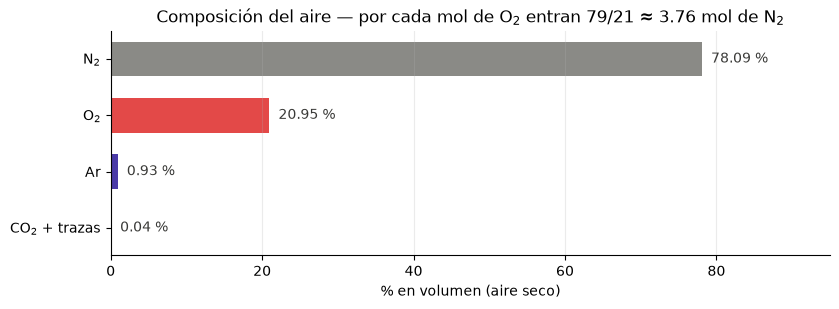

In [6]:
# Composición volumétrica del aire seco — gráfico generado por código
comp = {"N$_2$": 78.09, "O$_2$": 20.95, "Ar": 0.93, "CO$_2$ + trazas": 0.04}
colores = [COL["N2"], COL["O2"], COL["SO2"], COL["CO2"]]
fig, ax = plt.subplots(figsize=(8.5, 3.2))
y = np.arange(len(comp))
ax.barh(y, list(comp.values()), color=colores, height=0.62)
for yi, (nombre, v) in zip(y, comp.items()):
    ax.text(v + 1.2, yi, f"{v:.2f} %", va="center", fontsize=10, color=COL["tinta"])
ax.set_yticks(y, comp.keys()); ax.invert_yaxis()
ax.set_xlim(0, 95); ax.set_xlabel("% en volumen (aire seco)")
ax.set_title("Composición del aire — por cada mol de O$_2$ entran 79/21 ≈ 3.76 mol de N$_2$")
ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="x", alpha=0.25)
plt.tight_layout(); plt.show()

### 3.1 Combustión del Carbono con Aire

La combustión del carbono con aire implica la reacción del carbono (C) con el oxígeno (O2) presente en el aire para formar dióxido de carbono (CO2). La reacción es exotérmica, lo que significa que libera energía en forma de calor. A condiciones estándar, la reacción es la siguiente:

$$C + (O_2 + 3.76N_2) \rightarrow CO_2 + 3.76N_2$$

Es importante tener en cuenta que aunque el aire contiene nitrógeno, el nitrógeno no participa en la reacción de combustión a menos que la temperatura sea lo suficientemente alta. A temperaturas muy altas, el nitrógeno puede reaccionar con el oxígeno para formar óxidos de nitrógeno, pero esto generalmente no ocurre en la mayoría de las condiciones de combustión.

### 3.2 Balance general de la Combustión del Carbono con Aire

Para realizar un balance químico de la combustión del carbono con aire, debemos tener en cuenta que el aire es una mezcla de gases que contiene aproximadamente 78% de nitrógeno (N2) y 21% de oxígeno (O2) por volumen. Por lo tanto, para cada mol de oxígeno en el aire, hay aproximadamente 3.76 moles de nitrógeno. Esto significa que para cada mol de carbono que reacciona con el oxígeno en el aire, también hay 3.76 moles de nitrógeno presentes.

La reacción de combustión de $m$ moles de carbono con aire, incluyendo el nitrógeno, es la siguiente:

$$mC + m(O_2 + 3.76N_2) \rightarrow mCO_2 + 3.76\,m\,N_2$$

Como puedes ver, el nitrógeno aparece en ambos lados de la ecuación, lo que indica que no reacciona durante la combustión del carbono a condiciones estándar. El nitrógeno se considera un gas inerte en esta reacción.

In [9]:
# Ejercicio: calcular el poder calorífico de este combustible

## 4. Relación Aire Combustible

La relación aire-combustible (A/F) es una medida importante en muchos procesos de combustión, incluyendo la combustión de carbono. Esta relación se define como la proporción de la cantidad de aire al combustible presente en una mezcla de combustión.

### 4.1 A/F del Carbono con Aire

En la combustión completa, cada mol de carbono requiere 1 mol de oxígeno para reaccionar completamente y formar dióxido de carbono. Sin embargo, como el aire es una mezcla de gases que contiene aproximadamente 21% de oxígeno y 78% de nitrógeno, para cada mol de oxígeno en el aire, hay aproximadamente 3.76 moles de nitrógeno. Por lo tanto, para cada mol de carbono, se requieren aproximadamente 4.76 moles de aire (1 mol de oxígeno + 3.76 moles de nitrógeno) para la combustión completa.

Por lo tanto, la relación aire-combustible para la combustión completa del carbono es de aproximadamente 4.76:1. Esto significa que se requieren 4.76 moles de aire para quemar completamente 1 mol de carbono.

Es importante tener en cuenta que esta es la relación aire-combustible estequiométrica, que es la relación para la combustión completa. En la práctica, la relación aire-combustible puede ser mayor o menor que la relación estequiométrica, dependiendo de las condiciones específicas de la combustión.

In [10]:
# Ejercicio: calcular la relación aire combustible de este combustible

### Solución:

AFR Estequiométrico:

$$\frac{\text{Masa de Aire}}{\text{Masa de } C} = \frac{32 \, \text{g/mol} + 3.76 \times 28 \, \text{g/mol}}{12 \, \text{g/mol}} = \frac{137.28 \, \text{g/mol}}{12 \, \text{g/mol}} \approx 11.44 \, \text{kg de aire/kg de combustible}$$

Cuando $m > n$ (defecto de aire):

$$mC + n(O_2 + 3.76 N_2) \rightarrow n CO_2 + 3.76\,n\, N_2 + (m - n)C$$

Cuando $m < n$ (exceso de aire):

$$mC + n(O_2 + 3.76 N_2) \rightarrow m CO_2 + 3.76\,n\, N_2 + (n - m) O_2$$

### 4.2 A/F del Azufre con Aire

AFR Estequiométrico:

$$\frac{\text{Masa de Aire}}{\text{Masa de } S} = \frac{32 \, \text{g/mol} + 3.76 \times 28 \, \text{g/mol}}{32 \, \text{g/mol}} = \frac{137.28 \, \text{g/mol}}{32 \, \text{g/mol}} \approx 4.29 \, \text{kg de aire/kg de combustible}$$

Cuando $m > n$:

$$mS + n(O_2 + 3.76 N_2) \rightarrow n SO_2 + 3.76\,n\, N_2 + (m - n) S$$

Cuando $m < n$:

$$mS + n(O_2 + 3.76 N_2) \rightarrow m SO_2 + 3.76\,n\, N_2 + (n - m) O_2$$

### 4.3 A/F del Hidrógeno con Aire

AFR Estequiométrico:

$$\frac{\text{Masa de Aire}}{\text{Masa de } H_2} = \frac{0.5\times(32 \, \text{g/mol} + 3.76 \times 28 \, \text{g/mol})}{2 \times 1 \times 2\, \text{g/mol}} = \frac{0.5 \times 137.28 \, \text{g/mol}}{4 \, \text{g/mol}} \approx 34.32 \, \text{kg de aire/kg de combustible}$$

*(por cada 2 mol de $H_2$ se necesita 1 mol de $O_2$: $2H_2 + (O_2+3.76N_2) \rightarrow 2H_2O + 3.76N_2$; la masa de aire por kg de $H_2$ resulta $137.28/4$)*

Cuando $2n > m$ (exceso de aire):

$$mH_2 + n(O_2 + 3.76 N_2) \rightarrow m H_2O + 3.76\,n\, N_2 + \left(n - \tfrac{m}{2}\right) O_2$$

Cuando $2n < m$ (defecto de aire):

$$mH_2 + n(O_2 + 3.76 N_2) \rightarrow 2n\, H_2O + 3.76\,n\, N_2 + (m - 2n) H_2$$

### 4.4 Calor liberado en función del exceso de aire $\lambda$

Definimos $\lambda = AFR/AFR_{esteq}$. En **mezcla rica** ($\lambda<1$) falta oxígeno: solo reacciona la fracción $\lambda$ del combustible y el calor liberado cae. En **mezcla pobre** ($\lambda>1$) todo el combustible se quema, pero el aire en exceso añade masa (N$_2$ inerte) que no aporta energía: el calor **por kg de mezcla** se diluye. El máximo está en el punto estequiométrico $\lambda=1$:

$$q_{mezcla}(\lambda) = \frac{\min(1,\lambda)\; |\Delta H_c|}{M_{f} + \lambda\, \nu_{O_2}\, (M_{O_2} + 3.76\,M_{N_2})} \quad \left[\tfrac{kJ}{g\ \text{de mezcla}}\right]$$

donde $\nu_{O_2}$ [mol] es el oxígeno estequiométrico por mol de combustible y $M_i$ [g/mol] las masas molares.

In [7]:
# WIDGET 2 — calor liberado por kg de mezcla vs exceso de aire λ (sin sklearn: la curva es analítica)
FUELS = {  # nombre: (ΔHc [kJ/mol comb.], νO2 [mol/mol], M_fuel [g/mol], color)
    "C":     (-Hf["CO2"],                              1.0, M_C,            COL["CO2"]),
    "S":     (-Hf["SO2"],                              1.0, M_S,            COL["SO2"]),
    "H2":    (-Hf["H2O_g"],                            0.5, MM["Hydrogen"], COL["fuel"]),
    "C3H8":  (-(3*Hf["CO2"] + 4*Hf["H2O_g"] - Hf["C3H8"]), 5.0, MM["Propane"],  COL["H2O"]),
}
M_aire_mol = MM["Oxygen"] + 3.76 * MM["Nitrogen"]   # masa de aire por mol de O2 [g]

def q_mezcla(lam, dHc, nuO2, Mf):
    quemado = np.minimum(1.0, lam)                  # mezcla rica: solo reacciona fracción λ
    return quemado * dHc / (Mf + lam * nuO2 * M_aire_mol)

def calor_vs_lambda(lam=1.0, destacar="C3H8"):
    lams = np.linspace(0.2, 3.0, 300)
    fig, ax = plt.subplots(figsize=(8.5, 5))
    for nombre, (dHc, nuO2, Mf, c) in FUELS.items():
        grosor, alfa = (2.8, 1.0) if nombre == destacar else (1.6, 0.45)
        ax.plot(lams, q_mezcla(lams, dHc, nuO2, Mf), color=c, lw=grosor, alpha=alfa, label=nombre)
    dHc, nuO2, Mf, c = FUELS[destacar]
    q = q_mezcla(np.array([lam]), dHc, nuO2, Mf)[0]
    AFR = lam * nuO2 * M_aire_mol / Mf
    ax.plot(lam, q, "o", ms=9, color=c, mec="white", mew=1.5)
    regimen = "rica (falta O2)" if lam < 1 else ("estequiométrica" if lam == 1 else "pobre (exceso de aire)")
    ax.annotate(f"{destacar}: q = {q:.2f} kJ/g\nAFR = {AFR:.1f}, mezcla {regimen}",
                xy=(lam, q), xytext=(lam + 0.15, q + 0.25), fontsize=10, color=COL["tinta"],
                arrowprops=dict(arrowstyle="->", color=COL["tinta"], lw=1))
    ax.axvline(1.0, color=COL["tinta"], lw=0.9, ls=":", alpha=0.7)
    ax.text(1.02, ax.get_ylim()[1]*0.03, "λ = 1", fontsize=9, color=COL["tinta"])
    ax.set_xlabel("exceso de aire  λ = AFR/AFR$_{esteq}$"); ax.set_ylabel("calor liberado  [kJ/g de mezcla]")
    ax.set_title("El máximo de energía específica ocurre en la mezcla estequiométrica")
    ax.legend(title="combustible"); ax.grid(alpha=0.25); ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout(); plt.show()

interact(calor_vs_lambda,
         lam=FloatSlider(1.0, min=0.2, max=3.0, step=0.05, description="λ"),
         destacar=Dropdown(options=list(FUELS), value="C3H8", description="combustible"));

interactive(children=(FloatSlider(value=1.0, description='λ', max=3.0, min=0.2, step=0.05), Dropdown(descripti…

## 5. Balance de la Combustión de Combustibles Generales con Aire

Para un combustible compuesto por carbono (C), hidrógeno (H), nitrógeno (N) y azufre (S), el balance molar de la combustión se puede expresar de la siguiente manera:

$$C_mH_nN_oS_p + \left(m + \frac{n}{4} + p\right) (O_2 + 3.76N_2) \rightarrow mCO_2 + \frac{n}{2}H_2O + \frac{o}{2}N_2 + pSO_2 + \left(m + \frac{n}{4} + p\right)3.76N_2$$

donde:
- $C_mH_nN_oS_p$ representa el combustible, con $m$ moles de carbono, $n$ moles de hidrógeno, $o$ moles de nitrógeno y $p$ moles de azufre.
- $O_2 + 3.76N_2$ representa el aire, con 1 mol de oxígeno y 3.76 moles de nitrógeno por cada mol de oxígeno.
- Los productos incluyen dióxido de carbono, agua, nitrógeno y dióxido de azufre, así como el nitrógeno que no reacciona en la combustión.

*(Nota: el N del combustible sale como $N_2$ y no consume $O_2$; si el combustible contuviera oxígeno $C_mH_nO_qN_oS_p$, el término de aire se reduce en $q/2$.)*

Este balance molar de la combustión asegura que cada elemento se conserva en la reacción, es decir, la cantidad de cada elemento en los reactivos es igual a la cantidad en los productos. Esto es una aplicación de la ley de conservación de la masa.

### 5.1 Cálculo de la Relación Aire Combustible para Combustibles Generales

Para combustibles que contienen carbono (C), hidrógeno (H), nitrógeno (N) y azufre (S), la relación aire-combustible se calcula considerando la cantidad de oxígeno necesaria para oxidar completamente estos elementos a sus productos de combustión más estables, que son CO2, H2O, N2 y SO2, respectivamente.

Para cada mol de carbono en el combustible, se requiere 1 mol de O2 para formar CO2. Para cada mol de hidrógeno, se requiere 1/4 mol de O2 para formar H2O (es decir, 1/2 mol de O2 por mol de H2). El nitrógeno en el combustible generalmente se asume que se convierte en N2, que no requiere oxígeno. Para cada mol de azufre, se requiere 1 mol de O2 para formar SO2.

Por lo tanto, la cantidad total de oxígeno requerida para la combustión completa del combustible se puede calcular sumando la cantidad de oxígeno requerida para oxidar cada elemento. Luego, esta cantidad total de oxígeno se multiplica por 4.76 para obtener la cantidad total de aire requerida, ya que cada mol de oxígeno en el aire está acompañado por 3.76 moles de nitrógeno.

El poder calorífico del combustible se puede calcular a partir de la entalpía de formación de los productos de combustión y los reactivos. La entalpía de formación es la cantidad de energía liberada o absorbida cuando un compuesto se forma a partir de sus elementos constituyentes. Para la combustión, la entalpía de formación de los productos de combustión es menor que la de los reactivos, y la diferencia es la cantidad de energía liberada en la reacción, que es el poder calorífico del combustible.

In [12]:
# Ejercicio: calcular la relación aire combustible de forma general

#### Ejemplo: Propano

$$C_3H_8 + 5(O_2 + 3.76 N_2) \rightarrow 3 CO_2 + 4 H_2O + 5 (3.76 N_2)$$

AFR Estequiométrico:

$$\frac{\text{Masa de Aire}}{\text{Masa de } C_3H_8} = \frac{5 \times (32 \, \text{g/mol} + 3.76 \times 28 \, \text{g/mol})}{44 \, \text{g/mol}} = \frac{5 \times 137.28 \, \text{g/mol}}{44 \, \text{g/mol}} \approx 15.6 \, \text{kg de aire/kg de combustible}$$

Tomando en cuenta el balance estequiométrico se llegó a los casos no ideales.

Cuando $5m > n$ (defecto de aire):

$$m C_3H_8 + n (O_2 + 3.76 N_2) \rightarrow 3m\, CO_2 + (2n - 6m) H_2O + 3.76\,n\, N_2 + (20m - 4n) H$$

Cuando $5m < n$ (exceso de aire):

$$m C_3H_8 + n (O_2 + 3.76 N_2) \rightarrow 3m\, CO_2 + 4m\, H_2O + 3.76\,n\, N_2 + (n - 5m) O_2$$

*(Nota: en el caso rico el balance atómico se cierra con H atómico solo como artificio contable; en la realidad la combustión incompleta produce $CO$ y $H_2$ — se modela en la Lección 8.)*

In [8]:
# WIDGET 3 — combustible general C_mH_nN_oS_p con exceso de aire λ
def combustible_general(m=3, n=8, o=0, p=0, lam=1.2):
    nuO2 = m + n/4 + p                       # O2 estequiométrico [mol/mol comb.]
    M_f = m*M_C + n*M_H + o*M_N + p*M_S      # masa molar del combustible [g/mol]
    AFR_st = nuO2 * 4.76 * M_aire / M_f
    # productos de combustión completa con λ >= 1 (aire en exceso)
    lam_ef = max(lam, 1.0)
    prods = {"CO$_2$": m, "H$_2$O": n/2, "SO$_2$": p,
             "N$_2$": o/2 + 3.76*nuO2*lam_ef, "O$_2$": nuO2*(lam_ef - 1)}
    colores = [COL["CO2"], COL["H2O"], COL["SO2"], COL["N2"], COL["O2"]]
    # poder calorífico con ΔHf(combustible) ≈ 0 (combustible 'elemental', tipo carbón — aprox. Dulong)
    Q = m*(-Hf["CO2"]) + (n/2)*(-Hf["H2O_g"]) + p*(-Hf["SO2"])   # kJ/mol comb.
    PC = Q / M_f                                                  # kJ/g = MJ/kg
    aire = rf"{lam:.2f}\times{nuO2:.2f}\,(O_2 + 3.76\,N_2)"
    rhs = rf"{m}\,CO_2 + {n/2:g}\,H_2O" + (rf" + {p}\,SO_2" if p else "") + \
          rf" + {prods['N$_2$']:.2f}\,N_2" + (rf" + {prods['O$_2$']:.2f}\,O_2" if lam_ef > 1 else "")
    display(Math(rf"C_{{{m}}}H_{{{n}}}N_{{{o}}}S_{{{p}}} + {aire} \rightarrow {rhs}"))
    if lam < 1:
        print(f"⚠ λ = {lam:.2f} < 1 (mezcla rica): faltaría O2; la ecuación mostrada usa λ=1.")
    fig, ax = plt.subplots(figsize=(8.5, 4.2))
    nombres = list(prods); vals = [prods[k] for k in nombres]
    ax.bar(nombres, vals, color=colores, width=0.62)
    for xi, v in enumerate(vals):
        ax.text(xi, v + max(vals)*0.02, f"{v:.2f}", ha="center", fontsize=10, color=COL["tinta"])
    ax.set_ylabel("moles por mol de combustible")
    ax.set_title(f"AFR$_{{esteq}}$ = {AFR_st:.2f} | AFR = {lam*AFR_st:.2f} kg aire/kg comb. | "
                 f"PC ≈ {PC:.2f} MJ/kg (ΔH$_f$ comb. ≈ 0)")
    ax.grid(axis="y", alpha=0.25); ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout(); plt.show()

interact(combustible_general,
         m=IntSlider(3, min=1, max=12, description="m (C)"),
         n=IntSlider(8, min=0, max=26, description="n (H)"),
         o=IntSlider(0, min=0, max=2, description="o (N)"),
         p=IntSlider(0, min=0, max=2, description="p (S)"),
         lam=FloatSlider(1.2, min=0.8, max=3.0, step=0.05, description="λ"));

interactive(children=(IntSlider(value=3, description='m (C)', max=12, min=1), IntSlider(value=8, description='…

## 6. Temperatura de llama adiabática

Si la cámara de combustión no pierde calor, **toda** la energía liberada calienta los productos. La temperatura final $T_{ad}$ se obtiene del balance de energía:

$$\underbrace{|\Delta H_c|}_{\text{calor liberado}} = \sum_{prod} n_i \int_{298}^{T_{ad}} c_{p,i}^{0}(T)\, dT$$

donde $c^0_{p,i}(T)$ [J/(mol·K)] es el calor específico de gas ideal de cada producto, evaluado aquí con **CoolProp**. El aire en exceso ($\lambda>1$) agrega masa inerte que absorbe calor: $T_{ad}$ cae al alejarse del punto estequiométrico. *(Estimación superior: no consideramos disociación a alta temperatura.)*

In [9]:
# WIDGET 4 — temperatura de llama adiabática vs λ, con cp de gas ideal de CoolProp
T_grid = np.linspace(298.15, 3200.0, 240)
CP0 = {}   # tablas de entalpía sensible por especie: h(T)-h(298) [J/mol], precalculadas una vez
for fluido in ["CO2", "Water", "Nitrogen", "Oxygen"]:
    cp0 = np.array([PropsSI("Cp0molar", "T", float(T), "P", 101325.0, fluido) for T in T_grid])
    h_sens = np.concatenate([[0.0], np.cumsum(np.diff(T_grid) * 0.5 * (cp0[1:] + cp0[:-1]))])
    CP0[fluido] = h_sens

FUELS_TAD = {  # nombre: (m, n, ΔHc LHV [kJ/mol], M_fuel [g/mol])
    "CH4":  (1, 4,  -(Hf["CO2"] + 2*Hf["H2O_g"] - Hf["CH4"]),   MM["Methane"]),
    "C3H8": (3, 8,  -(3*Hf["CO2"] + 4*Hf["H2O_g"] - Hf["C3H8"]), MM["Propane"]),
    "H2":   (0, 2,  -Hf["H2O_g"],                                MM["Hydrogen"]),
}

def T_adiabatica(lam, m, n, dHc):
    nuO2 = m + n/4
    prods = {"CO2": m, "Water": n/2, "Nitrogen": 3.76*nuO2*lam, "Oxygen": nuO2*(lam-1)}
    def residuo(T):
        h = np.array([np.interp(T, T_grid, CP0[f]) for f in prods])
        return sum(ni * hi for ni, hi in zip(prods.values(), h)) / 1000.0 - dHc  # kJ
    return brentq(residuo, 300.0, 3199.0)

def llama_adiabatica(combustible="CH4", lam=1.0):
    m, n, dHc, Mf = FUELS_TAD[combustible]
    lams = np.linspace(1.0, 3.0, 36)
    Tads = np.array([T_adiabatica(l, m, n, dHc) for l in lams])
    T_actual = T_adiabatica(lam, m, n, dHc)
    fig, ax = plt.subplots(figsize=(8.5, 5))
    ax.plot(lams, Tads, color=COL["fuel"], lw=2.4)
    ax.plot(lam, T_actual, "o", ms=9, color=COL["O2"], mec="white", mew=1.5)
    ax.annotate(f"$T_{{ad}}$ = {T_actual:.0f} K = {T_actual-273.15:.0f} °C",
                xy=(lam, T_actual), xytext=(lam+0.18, T_actual+40), fontsize=11,
                color=COL["tinta"], arrowprops=dict(arrowstyle="->", color=COL["tinta"], lw=1))
    ax.set_xlabel("exceso de aire  λ"); ax.set_ylabel("$T_{ad}$  [K]")
    ax.set_title(f"Temperatura de llama adiabática — {combustible} "
                 f"(AFR$_{{esteq}}$ = {(m+n/4)*4.76*M_aire/Mf:.1f})")
    ax.grid(alpha=0.25); ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout(); plt.show()

interact(llama_adiabatica,
         combustible=Dropdown(options=list(FUELS_TAD), value="CH4", description="combustible"),
         lam=FloatSlider(1.0, min=1.0, max=3.0, step=0.05, description="λ"));

interactive(children=(Dropdown(description='combustible', options=('CH4', 'C3H8', 'H2'), value='CH4'), FloatSl…

## 7. Análisis de Combustibles

El análisis de combustibles se realiza para determinar la composición de un combustible. Hay dos tipos principales de análisis de combustibles: el análisis próximo y el análisis último.

El análisis de combustibles es el proceso de determinar las propiedades físicas y químicas de un combustible. Esto puede incluir la determinación del contenido de carbono, hidrógeno, oxígeno, nitrógeno y azufre, así como el calor de combustión.

El calor de combustión se mide en una **bomba calorimétrica** (esquema generado por código en la siguiente celda): el combustible se quema en una atmósfera de O$_2$ a volumen constante y el calor liberado se deduce del aumento de temperatura del agua que rodea la bomba.

El análisis de combustibles se puede realizar utilizando una variedad de técnicas, incluyendo la espectroscopia de infrarrojo cercano (NIR), la espectroscopia de absorción atómica (AAS), la espectroscopia de emisión óptica con plasma acoplado inductivamente (ICP-OES), y la cromatografía de gases (GC).

El análisis de combustibles es importante para determinar la eficiencia de combustión, la emisión de gases de efecto invernadero, y la calidad del combustible.

### 7.1 Análisis Próximo

El análisis próximo determina la cantidad de humedad, volátiles, carbono fijo y cenizas en un combustible. Estos componentes se miden como porcentajes en peso del combustible. El análisis próximo es útil para la clasificación de los combustibles y para la predicción de su comportamiento durante la combustión.

El análisis próximo proporciona la composición del combustible en términos de los siguientes componentes:

- **Humedad**: Es el contenido de agua en el combustible. Se expresa como un porcentaje en peso del combustible húmedo.
- **Volátiles**: Son los componentes del combustible que se vaporizan cuando se calienta el combustible. Incluyen gases y vapores que se liberan durante la combustión. Se expresan como un porcentaje en peso del combustible seco.
- **Carbono fijo**: Es la cantidad de carbono en el combustible que no se vaporiza durante la combustión. Se expresa como un porcentaje en peso del combustible seco.
- **Cenizas**: Son los residuos inorgánicos que quedan después de la combustión. Se expresan como un porcentaje en peso del combustible seco.

### 7.2 Análisis Último

El análisis último determina la cantidad de carbono, hidrógeno, nitrógeno, azufre y oxígeno en un combustible. Estos elementos se miden como porcentajes en peso del combustible. El análisis último es útil para calcular la relación aire-combustible necesaria para la combustión completa y para predecir las emisiones de la combustión.

Para un combustible con la composición $C_mH_nN_oS_p$, el análisis último proporciona los valores de $m$, $n$, $o$ y $p$. Estos valores se pueden utilizar para calcular la relación aire-combustible y para realizar el balance molar de la combustión, como se describió en la sección anterior.

El análisis último proporciona la composición del combustible en términos de los siguientes elementos:

- **Carbono (C)**: Se expresa como un porcentaje en peso del combustible seco.
- **Hidrógeno (H)**: Se expresa como un porcentaje en peso del combustible seco.
- **Nitrógeno (N)**: Se expresa como un porcentaje en peso del combustible seco.
- **Azufre (S)**: Se expresa como un porcentaje en peso del combustible seco.
- **Oxígeno (O)**: Se expresa como un porcentaje en peso del combustible seco. Se calcula por diferencia, es decir, 100% menos la suma de los porcentajes de los otros elementos.

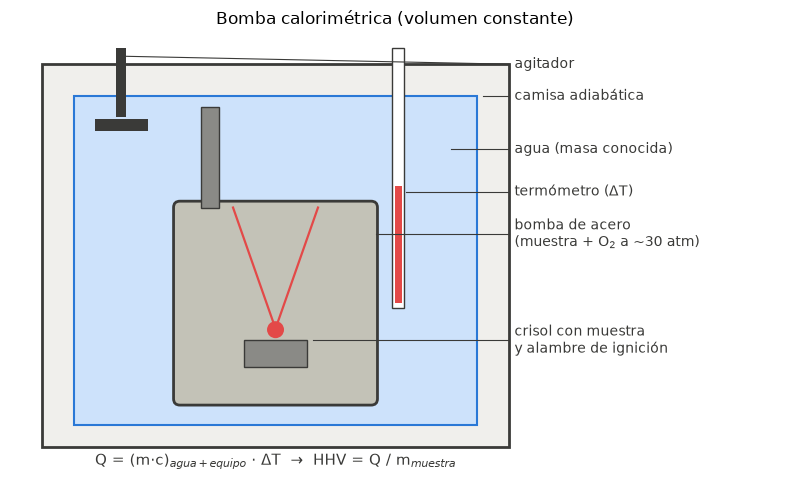

In [10]:
# Esquema de la bomba calorimétrica — generado por código (reemplaza imágenes estáticas de Wikipedia)
from matplotlib.patches import Rectangle, Circle, FancyBboxPatch

fig, ax = plt.subplots(figsize=(8.0, 6.4))
# camisa aislante y vaso con agua
ax.add_patch(Rectangle((0.6, 0.4), 8.8, 7.2, fc="#f0efec", ec=COL["tinta"], lw=2))
ax.add_patch(Rectangle((1.2, 0.8), 7.6, 6.2, fc="#cde2fb", ec="#2a78d6", lw=1.5))
# bomba (recipiente a presión con la muestra en O2)
ax.add_patch(FancyBboxPatch((3.2, 1.3), 3.6, 3.6, boxstyle="round,pad=0.12",
                            fc="#c3c2b7", ec=COL["tinta"], lw=2))
ax.add_patch(Rectangle((4.4, 1.9), 1.2, 0.5, fc="#8a8a86", ec=COL["tinta"]))   # crisol
ax.add_patch(Circle((5.0, 2.6), 0.16, fc=COL["O2"], ec="none"))                # chispa
ax.plot([4.2, 5.0, 5.8], [4.9, 2.62, 4.9], color=COL["O2"], lw=1.6)            # electrodos
# válvula de O2, termómetro y agitador
ax.add_patch(Rectangle((3.6, 4.9), 0.34, 1.9, fc="#8a8a86", ec=COL["tinta"]))
ax.add_patch(Rectangle((7.2, 3.0), 0.22, 4.9, fc="#ffffff", ec=COL["tinta"]))
ax.add_patch(Rectangle((7.245, 3.1), 0.13, 2.2, fc=COL["O2"], ec="none"))
ax.add_patch(Rectangle((2.0, 6.6), 0.18, 1.3, fc=COL["tinta"], ec="none"))
ax.add_patch(Rectangle((1.6, 6.35), 1.0, 0.22, fc=COL["tinta"], ec="none"))
etiquetas = [(9.5, 7.0, "camisa adiabática"), (9.5, 6.0, "agua (masa conocida)"),
             (9.5, 4.4, "bomba de acero\n(muestra + O$_2$ a ~30 atm)"),
             (9.5, 2.4, "crisol con muestra\ny alambre de ignición"),
             (9.5, 5.2, "termómetro (ΔT)"), (9.5, 7.6, "agitador")]
for x, y, s in etiquetas:
    ax.text(x, y, s, fontsize=10, va="center", color=COL["tinta"])
ax.plot([8.9, 9.4], [7.0, 7.0], color=COL["tinta"], lw=0.8)
ax.plot([8.3, 9.4], [6.0, 6.0], color=COL["tinta"], lw=0.8)
ax.plot([6.9, 9.4], [4.4, 4.4], color=COL["tinta"], lw=0.8)
ax.plot([5.7, 9.4], [2.4, 2.4], color=COL["tinta"], lw=0.8)
ax.plot([7.45, 9.4], [5.2, 5.2], color=COL["tinta"], lw=0.8)
ax.plot([2.1, 9.4], [7.75, 7.6], color=COL["tinta"], lw=0.8)
ax.text(5.0, 0.05, "Q = (m·c)$_{agua+equipo}$ · ΔT  →  HHV = Q / m$_{muestra}$",
        ha="center", fontsize=11, color=COL["tinta"])
ax.set_xlim(0, 14.5); ax.set_ylim(-0.4, 8.2); ax.set_aspect("equal"); ax.axis("off")
ax.set_title("Bomba calorimétrica (volumen constante)")
plt.tight_layout(); plt.show()

### 7.3 Conversión de Análisis Próximo a Análisis Último

Para convertir los resultados del análisis próximo a los del análisis último, se deben realizar los siguientes pasos:

1. **Corrección de la humedad**: Se debe corregir el contenido de humedad del combustible. Esto se hace restando el porcentaje de humedad del análisis próximo del 100% para obtener el porcentaje de combustible seco.
2. **Corrección de los volátiles**: Se debe corregir el contenido de volátiles. Esto se hace restando el porcentaje de volátiles del análisis próximo del 100% para obtener el porcentaje de combustible no volátil.
3. **Corrección del carbono fijo y las cenizas**: Se deben corregir el contenido de carbono fijo y las cenizas. Esto se hace restando el porcentaje de carbono fijo y las cenizas del análisis próximo del 100% para obtener el porcentaje de combustible orgánico.
4. **Cálculo de los elementos**: Se deben calcular los porcentajes de carbono, hidrógeno, nitrógeno, azufre y oxígeno. Esto se hace multiplicando el porcentaje de combustible orgánico por los porcentajes de estos elementos en el combustible orgánico.

### 7.4 Ejemplo de Conversión de análisis próximo a análisis último

La siguiente metodología ha sido adaptada y resulta relativamente buena para todo tipo de carbones térmicos, a excepción de antracitas y carbones con cantidades relativamente altas de resinas y ceras.

**a.** Se comienza con el **análisis próximo**, según se recibe, por ejemplo:

$$\begin{aligned}
\text{Materia volátil} & : 38\% \\
\text{Azufre} & : 2.4\% \\
\text{Carbón fijo} & : 52.3\% \\
\text{Humedad} & : 1.8\% \\
\text{Cenizas} & : 7.9\% \\
\text{Total} & : 100\% \\
\text{PCS} & : 13770 \ \text{BTU/lbm}
\end{aligned}$$

**b.** Se convierte el análisis próximo, según se recibe, a **base seca, sin cenizas**, dividiendo cada uno de los porcentajes anteriores por:

$$\frac{100 - \% \text{humedad} - \% \text{cenizas}}{100}$$

En este caso:

$$\frac{100 - 1.8 - 7.9}{100} = 0.903$$

Composición resultante:

$$\begin{aligned}
\text{Materia volátil} & : 42\% \\
\text{Azufre} & : 2.7\% \\
\text{Carbón fijo} & : 57.9\% \\
\text{Total} & : 100\% \\
\text{PCS} & : 15250 \ \text{BTU/lbm}
\end{aligned}$$

**c.** Se localiza la intersección de las líneas de **materia volátil sin cenizas** (42.1%) y del poder calorífico (15250 BTU/lbm) en la gráfica (ahora generada por código e interactiva en el widget siguiente). Esto corresponde a:

$$\%C_{\text{gráfica}} = 84.9\%, \quad \%H_{\text{gráfica}} = 5.9\%$$

Suponiendo un valor de **1.5%** para el nitrógeno en condición seca sin cenizas, la composición es:

$$\begin{aligned}
\%N_2 & = 1.5 \\
\%C & = 84.9 - 0.7 = 84.2 \\
\%H_2 & = 5.9 \\
\%S & = 2.7 \quad (\text{del análisis próximo}) \\
\%O_2 & = 100 - (84.2 + 5.9 + 2.7 + 1.5) = 5.7
\end{aligned}$$

**d.** Se convierte el análisis anterior a **análisis último, tal como se quema**, multiplicando los valores anteriores por el factor $0.903$:

$$\begin{aligned}
\%C & = 76 \\
\%H_2 & = 5.3 \\
\%N_2 & = 1.4 \\
\%S & = 2.4 \\
\%O_2 = 100 - \text{suma de los demás} & = 5.1 \\
\%\text{Humedad} & = 1.8 \\
\%\text{Cenizas} & = 7.9
\end{aligned}$$

In [11]:
# WIDGET 5 — conversión próximo → último con la gráfica regenerada por código
# La carta original (imagen estática de 230 KB) se reconstruye con dos familias de rectas
# calibradas para reproducir el ejemplo 7.4 (V=42.1 %, PCS=15250 → %C=84.9, %H=5.9).
# Validez: carbones térmicos; NO usar para antracitas ni carbones resinosos.
H_de_V = lambda V: 0.07 * V + 2.953                    # líneas horizontales: % volátiles daf
def C_de_PCS(PCS, H):                                  # diagonales: PCS daf [BTU/lbm]
    return 84.9 + (2.5e-4 * PCS + 2.0875 - H) / 0.0396

def proximo_a_ultimo(volatiles=38.0, S_prox=2.4, humedad=1.8, cenizas=7.9, PCS=13770.0, N_daf=1.5):
    f = (100.0 - humedad - cenizas) / 100.0            # factor a base seca sin cenizas (daf)
    V_daf, S_daf, PCS_daf = volatiles / f, S_prox / f, PCS / f
    H_daf = H_de_V(V_daf)
    C_graf = C_de_PCS(PCS_daf, H_daf)
    C_daf = C_graf - 0.7                               # corrección del método (paso c)
    O_daf = 100.0 - (C_daf + H_daf + S_daf + N_daf)
    ultimo = {"C": C_daf*f, "H": H_daf*f, "N": N_daf*f, "S": S_daf*f, "O": O_daf*f,
              "Humedad": humedad, "Cenizas": cenizas}
    # --- gráfica regenerada ---
    fig, ax = plt.subplots(figsize=(9, 6))
    Cs = np.linspace(64, 92, 100)
    for V in range(10, 45, 5):                         # horizontales de % volátiles
        ax.axhline(H_de_V(V), color=COL["tinta"], lw=1.0)
        ax.text(92.3, H_de_V(V), f"{V}", fontsize=9, va="center", color=COL["tinta"])
    for pcs in range(12000, 17000, 1000):              # diagonales de PCS
        Hs = 2.5e-4*pcs + 2.0875 - 0.0396*(Cs - 84.9)
        ax.plot(Cs, Hs, ls="--", color="#8a8a86", lw=1.2)
        ax.text(64.2, 2.5e-4*pcs + 2.0875 - 0.0396*(64.6 - 84.9), f"{pcs}",
                fontsize=9, color="#8a8a86")
    ax.plot(C_graf, H_daf, "o", ms=11, color=COL["O2"], mec="white", mew=1.8, zorder=5)
    ax.annotate(f"V={V_daf:.1f} %, PCS={PCS_daf:.0f}\n→ %C={C_graf:.1f}, %H={H_daf:.1f}",
                xy=(C_graf, H_daf), xytext=(C_graf-11, H_daf+0.42), fontsize=10,
                color=COL["tinta"], arrowprops=dict(arrowstyle="->", color=COL["tinta"], lw=1))
    ax.set_xlim(64, 94); ax.set_ylim(3.3, 6.8)
    ax.set_xlabel("% Carbono, base seca sin cenizas"); ax.set_ylabel("% Hidrógeno, base seca sin cenizas")
    ax.set_title("Carta de conversión próximo → último (adaptada; horizontales: % volátiles daf,\n"
                 "diagonales: PCS daf [BTU/lbm]; derecha: % volátiles)")
    ax.grid(alpha=0.2); plt.tight_layout(); plt.show()
    print(f"factor daf = {f:.3f} | base daf: V={V_daf:.1f} %, S={S_daf:.1f} %, PCS={PCS_daf:.0f} BTU/lbm")
    print("Análisis último, tal como se quema [% masa]:")
    for k, v in ultimo.items():
        print(f"  {k:8s} {v:6.1f}")
    print(f"  {'Total':8s} {sum(ultimo.values()):6.1f}")

interact(proximo_a_ultimo,
         volatiles=FloatSlider(38.0, min=15, max=45, step=0.5, description="volátiles %"),
         S_prox=FloatSlider(2.4, min=0, max=5, step=0.1, description="S %"),
         humedad=FloatSlider(1.8, min=0, max=15, step=0.2, description="humedad %"),
         cenizas=FloatSlider(7.9, min=0, max=20, step=0.2, description="cenizas %"),
         PCS=FloatSlider(13770, min=11000, max=15500, step=50, description="PCS BTU/lbm"),
         N_daf=FloatSlider(1.5, min=0.5, max=2.5, step=0.1, description="N daf %"));

interactive(children=(FloatSlider(value=38.0, description='volátiles %', max=45.0, min=15.0, step=0.5), FloatS…

### 7.5 Calidad del combustible

La calidad del combustible se refiere a las características físicas y químicas de un combustible que determinan su utilidad y eficiencia. Las características que se consideran al evaluar la calidad del combustible pueden incluir el contenido de energía, la tasa de combustión, la producción de humo y la producción de cenizas.

La calidad del combustible puede ser afectada por varios factores, incluyendo la fuente de la materia prima, el proceso de producción, el almacenamiento y el transporte. Por lo tanto, es importante realizar un análisis regular de la calidad del combustible para asegurar su rendimiento y eficiencia.

---
> **🔬 De la investigación al aula — biomasa de palma de aceite.** En el estudio *Computational Modeling of the Combustion Reaction Kinetics of the Oil Palm's Empty Fruit Bunch and Mesocarp Fiber* (línea de investigación del curso, `research_sources/Biofuels Combustion`), el análisis último del **raquis (EFB)** promediado de 7 estudios (C≈43.9 %, H≈6.2 %, O≈41.2 %, N≈0.6 %, S≈0.1 %, más K, P y Na) y el de la **fibra (PMF)** (C=51.52 %, H=5.45 %, O=40.91 %, N=1.89 %, S=0.23 %) alimentan exactamente los balances de este cuaderno: de ahí salen los AFR estequiométricos de **7.94** (EFB) y **8.63** (PMF) kg aire/kg y los objetivos de energía LHV·m. La Lección 8b reproduce el modelo cinético completo de ese artículo.

## Conclusión

La modelación de la combustión por **balances globales** entrega tres números de diseño: los coeficientes estequiométricos (cuánto aire), el poder calorífico (cuánta energía) y la temperatura de llama adiabática (qué tan caliente). Todos salen de dos principios — conservación de átomos y entalpías de formación — aplicables desde el H$_2$ hasta un carbón caracterizado por su análisis próximo/último. Lo que estos balances **no** dicen es cómo evoluciona la reacción en el tiempo: esa es la **cinética de la combustión**, tema de la Lección 8.

---
### Referencias
- Çengel, Y. A. & Boles, M. A. (2015). *Termodinámica*, 8ª ed. McGraw-Hill — Cap. 15, Tablas A-26/A-27.
- Turns, S. R. (2012). *An Introduction to Combustion*, 3ª ed. McGraw-Hill.
- Babcock & Wilcox (2005). *Steam: its generation and use*, 41ª ed. — análisis de combustibles.
- Bell, I. H. et al. (2014). CoolProp. *Ind. Eng. Chem. Res.*, 53(6), 2498–2508.